In [ ]:
import numpy as np
import cv2 as cv2
import matplotlib.pyplot as plt
import pandas as pd
plt.imshow

## LIBRARY

Library numpy untuk operasi numerik dan manipulasi array citra, cv2 untuk pemrosesan citra digital, matplotlib.pyplot untuk visualisasi citra dan histogram, serta pandas untuk pengolahan data, yang secara keseluruhan menjadi dasar dalam pengolahan citra digital terutama dalam manipulasi piksel dan analisis data.

## MENAMPILKAN CITRA

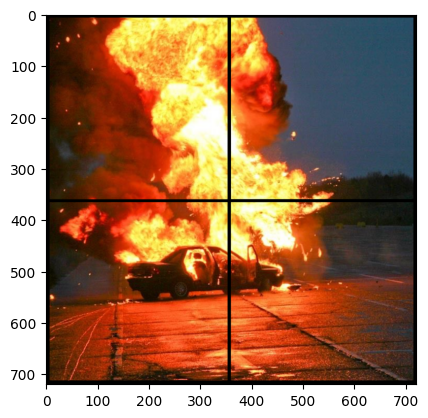

In [13]:
def show(img, title=""):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('on')
    
Meledak = plt.imread("Assets/Meledak.PNG")
show(Meledak)

## SLICING

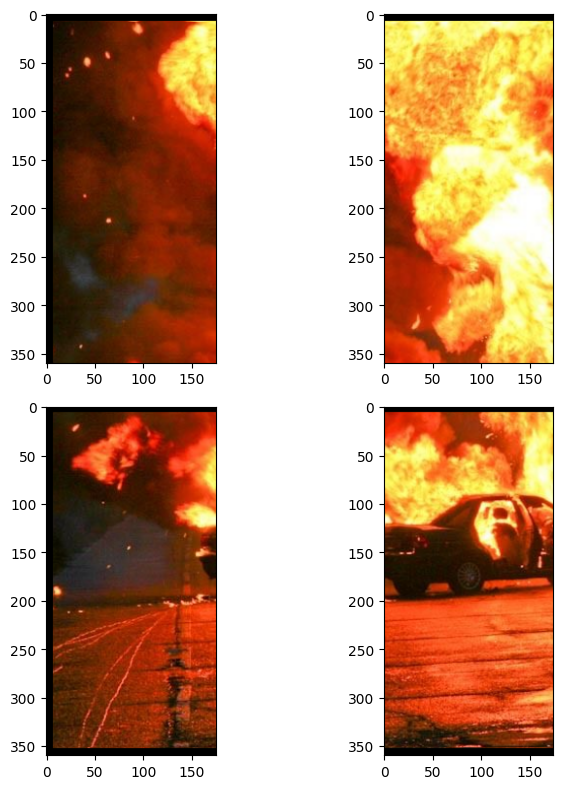

In [58]:
h, w = hasil.shape[:2]
a = h // 2
b = w // 2

image1 = hasil[:a, :b]   
image2 = hasil[:a, b:]  
image3 = hasil[a:, :b]  
image4 = hasil[a:, b:]  

fig, axs = plt.subplots(2, 2, figsize=(8, 8))

axs[0, 0].imshow(image1, cmap='gray')
axs[0, 1].imshow(image2, cmap='gray')
axs[1, 0].imshow(image3, cmap='gray')
axs[1, 1].imshow(image4, cmap='gray')

plt.tight_layout()
plt.show()


## PENGGABUNGAN

In [53]:
def join_horizontal(image_1, image_2):
    c1, c2 = np.array(image_1), np.array(image_2)
    
    h = max(c1.shape[0], c2.shape[0])
    w = c1.shape[1] + c2.shape[1]
    
    result = np.zeros((h, w), dtype=np.uint8)
    
    result[0:c1.shape[0], 0:c1.shape[1]] = c1
    result[0:c2.shape[0], c1.shape[1]:] = c2
    
    return result

def join_vertical(image_1, image_2):
    c1, c2 = np.array(image_1), np.array(image_2)
    
    h = c1.shape[0] + c2.shape[0]
    w = max(c1.shape[1], c2.shape[1])
    
    result = np.zeros((h, w), dtype=np.uint8)
    
    result[0:c1.shape[0], 0:c1.shape[1]] = c1
    result[c1.shape[0]:, 0:c2.shape[1]] = c2
    
    return result

def join_quadrants(q1, q2, q3, q4):
    top = join_horizontal(q1, q2)
    bottom = join_horizontal(q3, q4)
    full = join_vertical(top, bottom)
    return full

plt.figure(figsize=(8,8))
plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

## GRAYSCALE & EQUALIZATION

In [52]:
def ekualisasi(citra):

    height, width = citra.shape

    hist = np.zeros(256, dtype=int)

    # hitung histogram citra
    for y in range(height):
        for x in range(width):
            nilai_pixel = citra[y][x]
            hist[nilai_pixel] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    # hitung CDF
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    # normalisasi CDF
    cdf_normal = np.round(
        cdf * 255 / (height * width)
    ).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)

    # terapkan hasil ekualisasi
    for y in range(height):
        for x in range(width):
            hasil[y][x] = cdf_normal[citra[y][x]]

    return hasil


# =========================
# BACA GAMBAR
# =========================

citra = cv2.imread('gambar.jpg', 0)

# proses ekualisasi histogram
hasil_ekualisasi = ekualisasi(citra)

# =========================
# TAMPILKAN HASIL
# =========================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(citra, cmap='gray')
plt.title('Citra Asal')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hasil_ekualisasi, cmap='gray')
plt.title('Hasil Ekualisasi')
plt.axis('off')

plt.show()

AttributeError: 'NoneType' object has no attribute 'shape'